In [93]:
# Import statements
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import sympy as sp
from scipy.optimize import linear_sum_assignment

$R_0 = \dfrac{\beta}{(\gamma+\mu)}\Rightarrow \beta = R_0(\gamma+\mu)$

In [94]:
# Change estimates slightly for SIR model
N = 1e5  # Total population
gamma = 1/14  # Recovery rate (1/gamma is the infectious period)
R_0 = 4 # Basic reproduction number estimated for alpha variant
mu = 0.00003424657  # Birth and death rate
beta0 = R_0 * (gamma+mu)
betat = lambda x: beta0

In [95]:
beta0

0.28585127199428567

In [96]:
def test_int(X, t, betat, gamma, mu):
    S = -betat(t)*X[0]*X[1]-mu*X[0]+mu
    I = betat(t)*X[0]*X[1]-(mu+gamma)*X[1]
    R = gamma*X[1]-mu*X[2]

    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0]], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0]],
                   ])
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1]],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1]],
                   ])

    Θ = np.matrix([[X[3],X[4]],
                   [X[4],X[5]],
                   ])

    K = A*Θ +Θ*A.transpose()+B
    return [S, I, R, K[0,0], K[0,1], K[1,1]]

def jac(X, t, betat, gamma, mu):
    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0]], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0]],
                   ])
    return A

def Q_calc(X, t, betat, gamma, mu):
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1]],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1]],
                   ])
    return B

In [97]:
def sir_model(X, t, betat, gamma, mu):
    S, I, R = X[0], X[1], X[2]
    dSdt = -betat(t) * S * I - mu * S + mu
    dIdt = betat(t) * S * I - (mu + gamma) * I
    dRdt = gamma * I - mu * R
    return [dSdt, dIdt, dRdt]

In [98]:
# Define symbols
s, i, g, m, beta = sp.symbols('s i g m beta', real=True, positive=True)
lam = sp.symbols('lam')

# Define the Jacobian matrix
J = sp.Matrix([
    [-m - beta*i,-beta*s],
    [beta*i,beta*s-g-m]
])

# Compute the characteristic polynomial det(J - lambda*I)
char_poly = J.charpoly(lam)
char_poly_expr = char_poly.as_expr()

# Compute the discriminant of the characteristic polynomial
discriminant = sp.discriminant(char_poly_expr, lam)

# Simplify a bit for readability
discriminant_simplified = sp.simplify(discriminant)

# H(t) determinant
det_H = m*(m+g)+beta*m*(i-s)+beta*g*i-beta**2*(i+s)**2/4

In [99]:
char_poly_expr

beta*g*i + beta*i*m - beta*m*s + g*m + lam**2 + lam*(beta*i - beta*s + g + 2*m) + m**2

In [100]:
discriminant_simplified

beta**2*i**2 - 2*beta**2*i*s + beta**2*s**2 - 2*beta*g*i - 2*beta*g*s + g**2

In [101]:
det_H

-beta**2*(i + s)**2/4 + beta*g*i + beta*m*(i - s) + m*(g + m)

In [102]:
params = {
    'beta': beta0,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': 0.00003424657    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0.01, 0.99, 200)
i_vals = np.linspace(0.001, 0.99, 200)
S, I = np.meshgrid(s_vals, i_vals)

# Substitute into the symbolic discriminant
subs_dict = {
    's': S,
    'i': I,
    'beta': params['beta'],
    'g': params['g'],
    'mu': params['mu']
}

# Lambdify the discriminant
from sympy import lambdify

discriminant_func = lambdify((s, i, beta, g, m), discriminant_simplified, 'numpy')

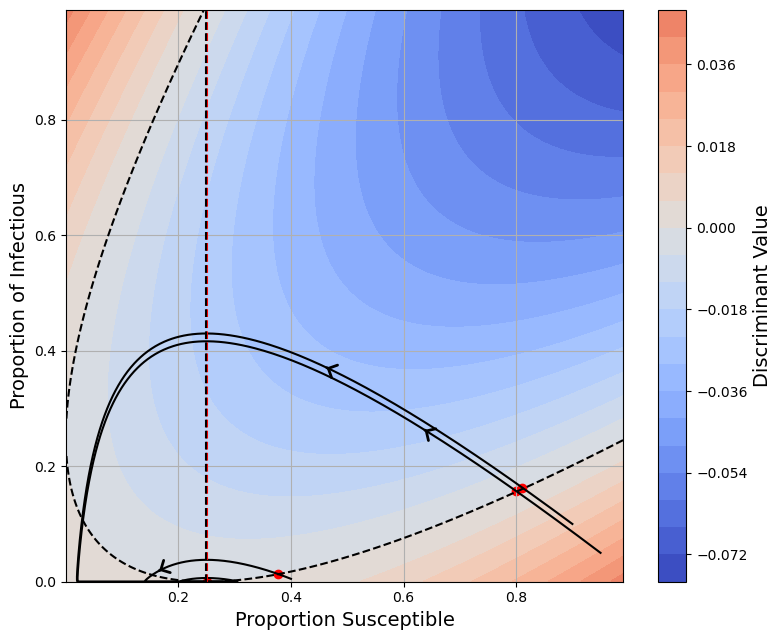

In [103]:
params = {
    'beta': beta0,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': mu    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0.001, 0.99, 400)
i_vals = np.linspace(0.001, 0.99, 400)
S, I = np.meshgrid(s_vals, i_vals)

# Lambdify the discriminant
from sympy import lambdify

discriminant_func = lambdify((s, i, beta, g, m), discriminant_simplified, 'numpy')

# Evaluate over the grid
D_vals = discriminant_func(S, I, params['beta'],params['g'], params['mu'])

icS = np.array([0.9, 0.95])
icI = 1 - icS
ts2 = np.linspace(0,10000,100000)
# Plot the discriminant
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(S, I, D_vals, levels=20, vmin=-np.max(np.abs(D_vals)),vmax=np.max(np.abs(D_vals)),cmap='coolwarm')
cbar = plt.colorbar(contour)
# Change tick label size
cbar.set_label('Discriminant Value', fontsize=14)
skip = 400
plt.contour(S, I, D_vals, levels=[0], colors='k', linewidths=1.5, linestyles='--')
for s0, i0 in zip(icS,icI):
    cst_theory = odeint(test_int,[s0,i0,0,0,0,0],ts2,args=(betat,1/14,0.00003424657))
    eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts2[i],betat,1/14,0.00003424657)) for i in range(len(ts2))])
    id1 = np.where(np.iscomplex(eigvals_theory[:,0]))[0][0]
    plt.scatter(cst_theory[id1,0], cst_theory[id1,1], color='red')
    plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
    # single arrow
    mid = len(cst_theory)//1000
    plt.annotate('',
                 xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                 xytext=(cst_theory[mid,0], cst_theory[mid,1]),
                arrowprops=dict(
                     arrowstyle='->,head_length=0.5,head_width=0.5',
                     color='black',
                     lw=2))
cst_theory = odeint(test_int,[0.4,0.005,1-0.4-0.005,0,0,0],ts2,args=(betat,1/14,0.00003424657))
eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts2[i],betat,1/14,0.00003424657)) for i in range(len(ts2))])
id1 = np.where(np.iscomplex(eigvals_theory[:,0]))[0][0]
id2 = np.where(np.iscomplex(eigvals_theory[:,0]))[0][-1]
plt.scatter(cst_theory[id1,0], cst_theory[id1,1], color='red')
plt.scatter(cst_theory[id2,0], cst_theory[id2,1], color='red')
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
# single arrow
mid = len(cst_theory)//80
plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))


plt.vlines(x=1/4, ymin=0, ymax=0.99, color='red', linestyle='--')
plt.vlines(x=gamma/beta0, ymin=0, ymax=0.99, color='black', linestyle='--')
plt.xlabel('Proportion Susceptible',fontsize = 14)
plt.ylabel('Proportion of Infectious',fontsize = 14)
plt.grid(True)
plt.ylim(0,None)
plt.tight_layout()
plt.show()

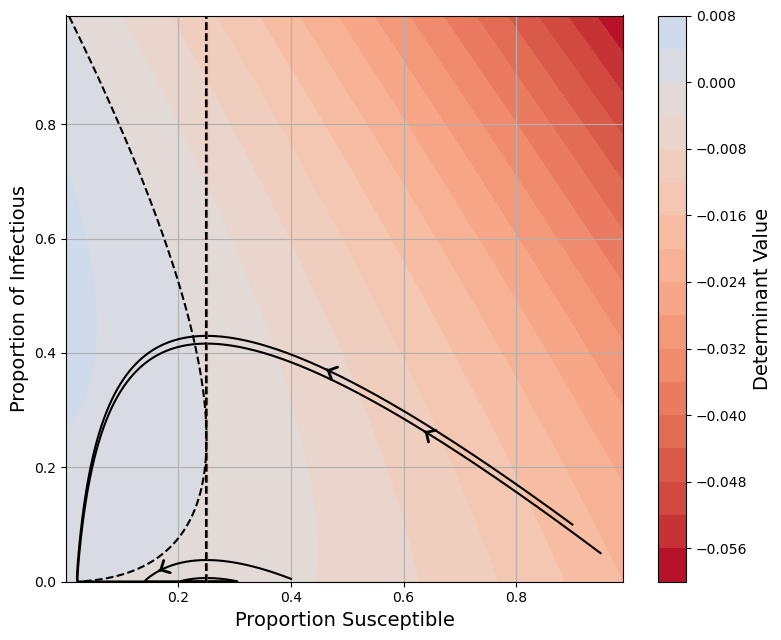

In [104]:
params = {
    'beta': beta0,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': mu    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0.001, 0.99, 400)
i_vals = np.linspace(0.001, 0.99, 400)
S, I = np.meshgrid(s_vals, i_vals)

# Lambdify the discriminant
from sympy import lambdify

det_func = lambdify((s, i, beta, g, m), det_H, 'numpy')

# Evaluate over the grid
D_vals = det_func(S, I, params['beta'],params['g'], params['mu'])

icS = np.array([0.9, 0.95])
icI = 1 - icS
ts = np.linspace(0,500,5000)
# Plot the det
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(S, I, D_vals, levels=20, vmin=-np.max(np.abs(D_vals)),vmax=np.max(np.abs(D_vals)),cmap='coolwarm_r')
cbar = plt.colorbar(contour)
# Change tick label size
cbar.set_label('Determinant Value', fontsize=14)
plt.contour(S, I, D_vals, levels=[0], colors='k', linewidths=1.5, linestyles='--')
for s0, i0 in zip(icS,icI):
    cst_theory = odeint(test_int,[s0,i0,0,0,0,0],ts2,args=(betat,1/14,0.00003424657))
    plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
    # single arrow
    mid = len(cst_theory)//1000
    plt.annotate('',
                 xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                 xytext=(cst_theory[mid,0], cst_theory[mid,1]),
                arrowprops=dict(
                     arrowstyle='->,head_length=0.5,head_width=0.5',
                     color='black',
                     lw=2))
cst_theory = odeint(test_int,[0.4,0.005,1-0.4-0.005,0,0,0],ts2,args=(betat,1/14,0.00003424657))
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
# single arrow
mid = len(cst_theory)//80
plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))


plt.vlines(x=1/4, ymin=0, ymax=0.99, color='red', linestyle='--')
plt.vlines(x=gamma/beta0, ymin=0, ymax=0.99, color='black', linestyle='--')
plt.xlabel('Proportion Susceptible',fontsize = 14)
plt.ylabel('Proportion of Infectious',fontsize = 14)
plt.grid(True)
plt.ylim(0,None)
plt.tight_layout()
plt.show()

In [105]:
# helper functions for fixing eigenbasis
def match_and_phase_align(V_prev, V_curr):
    # match columns
    M = np.abs(V_prev.conj().T @ V_curr)
    row_ind, col_ind = linear_sum_assignment(-M)
    Vc = V_curr[:, col_ind]

    # phase-align each column to previous
    for i in range(V_prev.shape[1]):
        s = np.vdot(V_prev[:, i], Vc[:, i])   # v_prev^H v_curr
        if np.abs(s) > 0:
            phase = s / np.abs(s)
            Vc[:, i] = Vc[:, i] * np.conj(phase)
        else:
            # fallback: if dot is zero, try sign or leave as is
            pass
    return Vc, col_ind

# ICs and theoretical solutions
X0 = [0.4, 0.005, 1-0.4-0.005, 0, 0, 0]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]

# ICs and Outputs
eig_J_real, eig_J_imag = [], []
eig_sym, num_abscissa, proj_amp, dVarI = [], [], [], []
det_sym = []
VarI_modal, g_store, diag_contrib, cross_contrib = [], [], [], []
VarI_H, g_H_store, diag_contrib_H, cross_contrib_H = [], [], [], []
V_store, Vinv_store = [], []
diag_dot, cross_dot, noise_dot = [], [], []
Arot_norm = [0]
e_I = np.array([0,1])

def varI_from_modal(V, Sigma, e_I):
    """
    Compute modal variance and its components for possibly complex eigenvectors.

    Returns:
        full_var : Re[g^H S g]
        g        : modal projection vector (shape (n,))
        diag_part, cross_part : variance decomposition
    """
    V_inv = np.linalg.inv(V)
    # Hermitian transform because V may be complex
    S_modal = V_inv @ Sigma @ V_inv.conj().T       # S = V^{-1} Σ V^{-*}

    # g = V^H e_I  (ensure it's a 1D complex vector)
    g_J = (V.conj().T @ e_I.reshape(-1, 1)).ravel()

    # Now both g and (S_modal @ g) are 1D (length n)
    full = np.real(np.vdot(g_J, S_modal @ g_J))        # vdot = g* @ (S_modal @ g)
    diag_part = np.real(np.sum((np.abs(g_J)**2) * np.real(np.diag(S_modal))))
    cross_part = full - diag_part
    return full, g_J, diag_part, cross_part

def varI_from_H(H, Sigma, e_I):
    """
    Variance decomposition of I in the basis of H = (J + J^T)/2.
    """
    w_H, W = np.linalg.eigh(H)
    W = np.array(W)
    S_H = W.T @ Sigma @ W
    g_H = (W.T @ e_I.reshape(-1, 1)).ravel()
    full = float(g_H.T @ S_H @ g_H)
    diag_part = float(np.sum((g_H**2) * np.diag(S_H)))
    cross_part = full - diag_part
    return full, g_H, diag_part, cross_part

for idx, X in enumerate(sol):
    A = jac(X, ts[idx], betat, gamma, mu)
    Q = Q_calc(X, ts[idx], betat, gamma, mu)
    Sigma = np.array([[X[3], X[4]], [X[4], X[5]]])
    
    # J(t) values
    w, V = np.linalg.eig(A)
    V_inv = np.linalg.inv(V)
    eig_J_real.append(np.real(w))
    eig_J_imag.append(np.imag(w))
    # V_store.append(V.copy())
    Vinv_store.append(V_inv.copy())
    Lambda = np.diag(w)

    # Var(I) modal
    S_modal = V_inv @ Sigma @ V_inv.conj().T
    Q_modal = np.array(V_inv @ Q @ V_inv.conj().T)

    # dVar(I)/dt
    K = A @ Sigma + Sigma @ A.T + Q
    dVarI.append(K[1,1])
    
    # H(t)
    sym = (A + A.T)/2
    ws, vs = np.linalg.eig(sym)
    eig_sym.append(ws)
    num_abscissa.append(np.max(ws))
    det_sym.append(np.linalg.det(sym))
    vmax = vs[:, np.argmax(ws)]
    G = vmax.T @ Q @ vmax
    proj_amp.append(np.real(G))
    
    
    # Var(I) decomp
    varI_m, g_J, dpart, cpart = varI_from_modal(np.array(V), Sigma, e_I)
    VarI_modal.append(varI_m)
    g_store.append(g_J)
    diag_contrib.append(dpart)
    cross_contrib.append(cpart)

    # dVar(I)/dt decomp
    diag_d = np.sum(2*np.real(np.diag(Lambda)) * (np.abs(g_J)**2) * np.real(np.diag(S_modal)))
    cross_d = np.real(K[1,1] - diag_d - np.real(np.vdot(g_J, Q_modal @ g_J)))
    noise_d = Q[1,1]
    diag_dot.append(diag_d)
    cross_dot.append(cross_d)
    noise_dot.append(noise_d)

    # H(t) var
    varI_h, g_h, dpart_h, cpart_h = varI_from_H(sym, Sigma, e_I)
    VarI_H.append(varI_h)
    g_H_store.append(g_h)
    diag_contrib_H.append(dpart_h)
    cross_contrib_H.append(cpart_h)

    # Rotation rate
    if idx == 0:
        V_prev = V.copy()
        V_store = [V.copy()]
        perm_store = [np.arange(V.shape[1])]
    else:
        V_aligned, perm = match_and_phase_align(V_prev, V)
        # optional: detect 2x2 blocks where eigenvalues are close and align subspace instead
        V_store.append(V_aligned.copy())
        perm_store.append(perm)
        # estimate derivative:
        dt = ts[idx] - ts[idx-1]
        dV = (V_aligned - V_prev) / dt
        A_est = np.linalg.inv(V_prev) @ dV
        Arot_norm.append(np.linalg.norm(A_est, ord='fro'))
        V_prev = V_aligned.copy()

# Arrays for plotting
eig_J_real = np.array(eig_J_real)
eig_J_imag = np.array(eig_J_imag)
eig_sym = np.array(eig_sym)
num_abscissa = np.array(num_abscissa)
proj_amp = np.array(proj_amp).flatten()
dVarI = np.array(dVarI)
VarI_modal = np.array(VarI_modal)
diag_contrib = np.array(diag_contrib)
cross_contrib = np.array(cross_contrib)
g_store = np.array(g_store)
VarI_H = np.array(VarI_H)
diag_contrib_H = np.array(diag_contrib_H)
cross_contrib_H = np.array(cross_contrib_H)
g_H_store = np.array(g_H_store)
diag_dot = np.array(diag_dot)
cross_dot = np.array(cross_dot)
noise_dot = np.array(noise_dot)

/tmp/ipykernel_333600/1002991493.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  Vc[:, i] = Vc[:, i] * np.conj(phase)


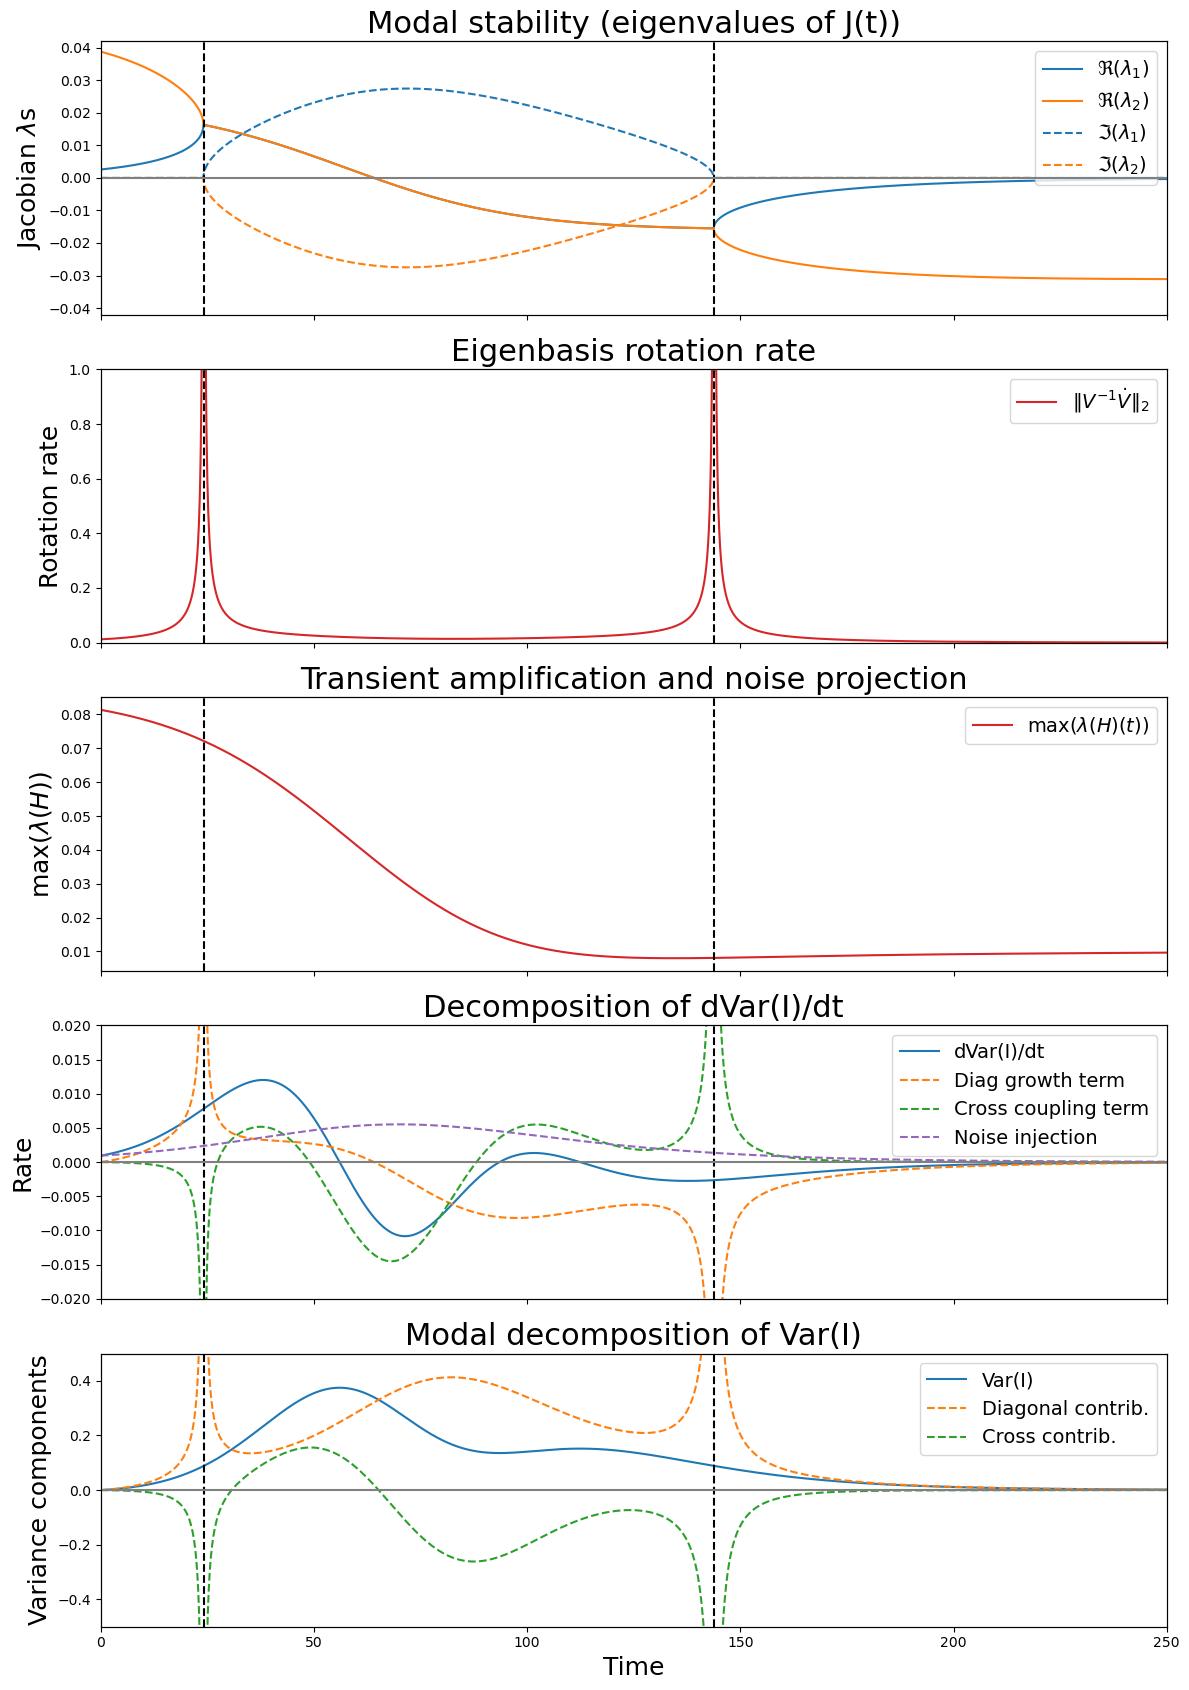

In [106]:
fig, axs = plt.subplots(5, 1, figsize=(12, 17), sharex=True)

# J(t)
axs[0].plot(ts, eig_J_real[:,0], color='tab:blue', label=r'$\Re(\lambda_1)$')
axs[0].plot(ts, eig_J_real[:,1], color='tab:orange', label=r'$\Re(\lambda_2)$')
axs[0].plot(ts, eig_J_imag[:,0], '--', color='tab:blue', label=r'$\Im(\lambda_1)$')
axs[0].plot(ts, eig_J_imag[:,1], '--', color='tab:orange', label=r'$\Im(\lambda_2)$')
axs[0].set_ylabel(r"Jacobian $\lambda$s", fontsize=18)
axs[0].set_title("Modal stability (eigenvalues of J(t))", fontsize=22)
axs[0].legend(loc='upper right', fontsize=14)
axs[0].set_ylim(-0.042,0.042)

# Rotation rate
axs[1].plot(ts, Arot_norm, color='tab:red', label=r"$\|V^{-1}\dot V\|_2$")
axs[1].set_ylabel("Rotation rate", fontsize=18)
axs[1].set_title("Eigenbasis rotation rate", fontsize=22)
axs[1].legend(fontsize=14)
axs[1].set_ylim((0,1))

# H(t)
axs[2].plot(ts, num_abscissa, color='tab:red', label=r'$\max(\lambda(H)(t))$')
axs[2].set_ylabel(r'$\max(\lambda(H))$', fontsize=18)
axs[2].set_title("Transient amplification and noise projection", fontsize=22)
axs[2].legend(loc='upper right', fontsize=14)

# dVar(I)/dt
axs[3].plot(ts, dVarI, label="dVar(I)/dt", color="tab:blue")
axs[3].plot(ts, diag_dot, '--', label="Diag growth term", color="tab:orange")
axs[3].plot(ts, cross_dot, '--', label="Cross coupling term", color="tab:green")
axs[3].plot(ts, noise_dot, '--', label="Noise injection", color="tab:purple")
axs[3].set_title("Decomposition of dVar(I)/dt", fontsize=22)
axs[3].set_ylabel("Rate",fontsize=18)
axs[3].legend(fontsize=14)
axs[3].set_ylim(-0.02,0.02)

# Var(I)
axs[4].plot(ts, VarI_modal, label="Var(I)", color='tab:blue')
axs[4].plot(ts, diag_contrib, '--', label="Diagonal contrib.", color='tab:orange')
axs[4].plot(ts, cross_contrib, '--', label="Cross contrib.", color='tab:green')
axs[4].set_ylabel("Variance components", fontsize=18)
axs[4].set_title("Modal decomposition of Var(I)", fontsize=22)
axs[4].legend(fontsize=14)
axs[4].set_ylim((-0.5,0.5))
axs[4].set_xlabel("Time", fontsize=18)

# Axes limits
for idx in range(5):
    ax = axs[idx].twinx()
    ax.vlines([ts[241],ts[1437]],0,1,linestyles='--',color='k')
    ax.set_ylim(0,1)
    ax.set_yticks([])
    if not (idx in [1,2]):
        ax.hlines(0.5,0,250,'grey')
    axs[idx].set_xlim(0,250)

plt.tight_layout()
plt.show()

(0.0, 0.42)

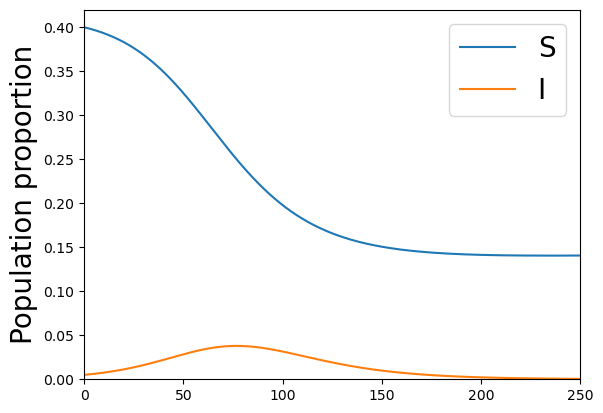

In [107]:
plt.plot(ts, S, label='S', color='tab:blue')
plt.plot(ts, I, label='I', color='tab:orange')
# plt.plot(ts, R, label='R', color='tab:green')
plt.ylabel("Population proportion",fontsize=20)
plt.legend(loc='upper right',fontsize=20)
plt.xlim(0,250)
plt.ylim(0,0.42)

In [108]:
# ICs
X0 = [0.95, 0.05, 0, 0, 0, 0]

# Get theoreticals
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]

# Inits and outputs
eig_J_real, eig_J_imag = [], []
eig_sym, num_abscissa, proj_amp, dVarI = [], [], [], []
det_sym = []
VarI_modal, g_store, diag_contrib, cross_contrib = [], [], [], []
VarI_H, g_H_store, diag_contrib_H, cross_contrib_H = [], [], [], []
V_store, Vinv_store = [], []
diag_dot, cross_dot, noise_dot = [], [], []
e_I = np.array([0,1])
Arot_norm = [0]

for idx, X in enumerate(sol):
    A = jac(X, ts[idx], betat, gamma, mu)
    Q = Q_calc(X, ts[idx], betat, gamma, mu)
    Sigma = np.array([[X[3], X[4]], [X[4], X[5]]])
    
    # Modal eigenvalues/eigenvectors
    w, V = np.linalg.eig(A)
    V_inv = np.linalg.inv(V)
    eig_J_real.append(np.real(w))
    eig_J_imag.append(np.imag(w))
    Vinv_store.append(V_inv.copy())
    Lambda = np.diag(w)

    # Modal noise
    S_modal = V_inv @ Sigma @ V_inv.conj().T
    Q_modal = np.array(V_inv @ Q @ V_inv.conj().T)

    # dVar(I)/dt
    K = A @ Sigma + Sigma @ A.T + Q
    dVarI.append(K[1,1])
    
    # H(t)
    sym = (A + A.T)/2
    ws, vs = np.linalg.eig(sym)
    eig_sym.append(ws)
    num_abscissa.append(np.max(ws))
    det_sym.append(np.linalg.det(sym))
    
    # H(t) var
    vmax = vs[:, np.argmax(ws)]
    G = vmax.T @ Q @ vmax
    proj_amp.append(np.real(G))
    
    # Var decomp
    varI_m, g_J, dpart, cpart = varI_from_modal(np.array(V), Sigma, e_I)
    VarI_modal.append(varI_m)
    g_store.append(g_J)
    diag_contrib.append(dpart)
    cross_contrib.append(cpart)

    # dVar decomp
    diag_d = np.sum(2*np.real(np.diag(Lambda)) * (np.abs(g_J)**2) * np.real(np.diag(S_modal)))
    cross_d = np.real(K[1,1] - diag_d - np.real(np.vdot(g_J, Q_modal @ g_J)))
    noise_d = Q[1,1]
    diag_dot.append(diag_d)
    cross_dot.append(cross_d)
    noise_dot.append(noise_d)

    # Hvar decomp
    varI_h, g_h, dpart_h, cpart_h = varI_from_H(sym, Sigma, e_I)
    VarI_H.append(varI_h)
    g_H_store.append(g_h)
    diag_contrib_H.append(dpart_h)
    cross_contrib_H.append(cpart_h)

    # Fix eigenvector rotations
    if idx == 0:
        V_prev = V.copy()
        V_store = [V.copy()]
        perm_store = [np.arange(V.shape[1])]
    else:
        V_aligned, perm = match_and_phase_align(V_prev, V)
        V_store.append(V_aligned.copy())
        perm_store.append(perm)
        # estimate derivative:
        dt = ts[idx] - ts[idx-1]
        dV = (V_aligned - V_prev) / dt
        A_est = np.linalg.inv(V_prev) @ dV
        Arot_norm.append(np.linalg.norm(A_est, ord='fro'))
        V_prev = V_aligned.copy()

# Arrays for plotting
eig_J_real = np.array(eig_J_real)
eig_J_imag = np.array(eig_J_imag)
eig_sym = np.array(eig_sym)
num_abscissa = np.array(num_abscissa)
proj_amp = np.array(proj_amp).flatten()
dVarI = np.array(dVarI)
VarI_modal = np.array(VarI_modal)
diag_contrib = np.array(diag_contrib)
cross_contrib = np.array(cross_contrib)
g_store = np.array(g_store)
VarI_H = np.array(VarI_H)
diag_contrib_H = np.array(diag_contrib_H)
cross_contrib_H = np.array(cross_contrib_H)
g_H_store = np.array(g_H_store)
diag_dot = np.array(diag_dot)
cross_dot = np.array(cross_dot)
noise_dot = np.array(noise_dot)


/tmp/ipykernel_333600/1002991493.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  Vc[:, i] = Vc[:, i] * np.conj(phase)


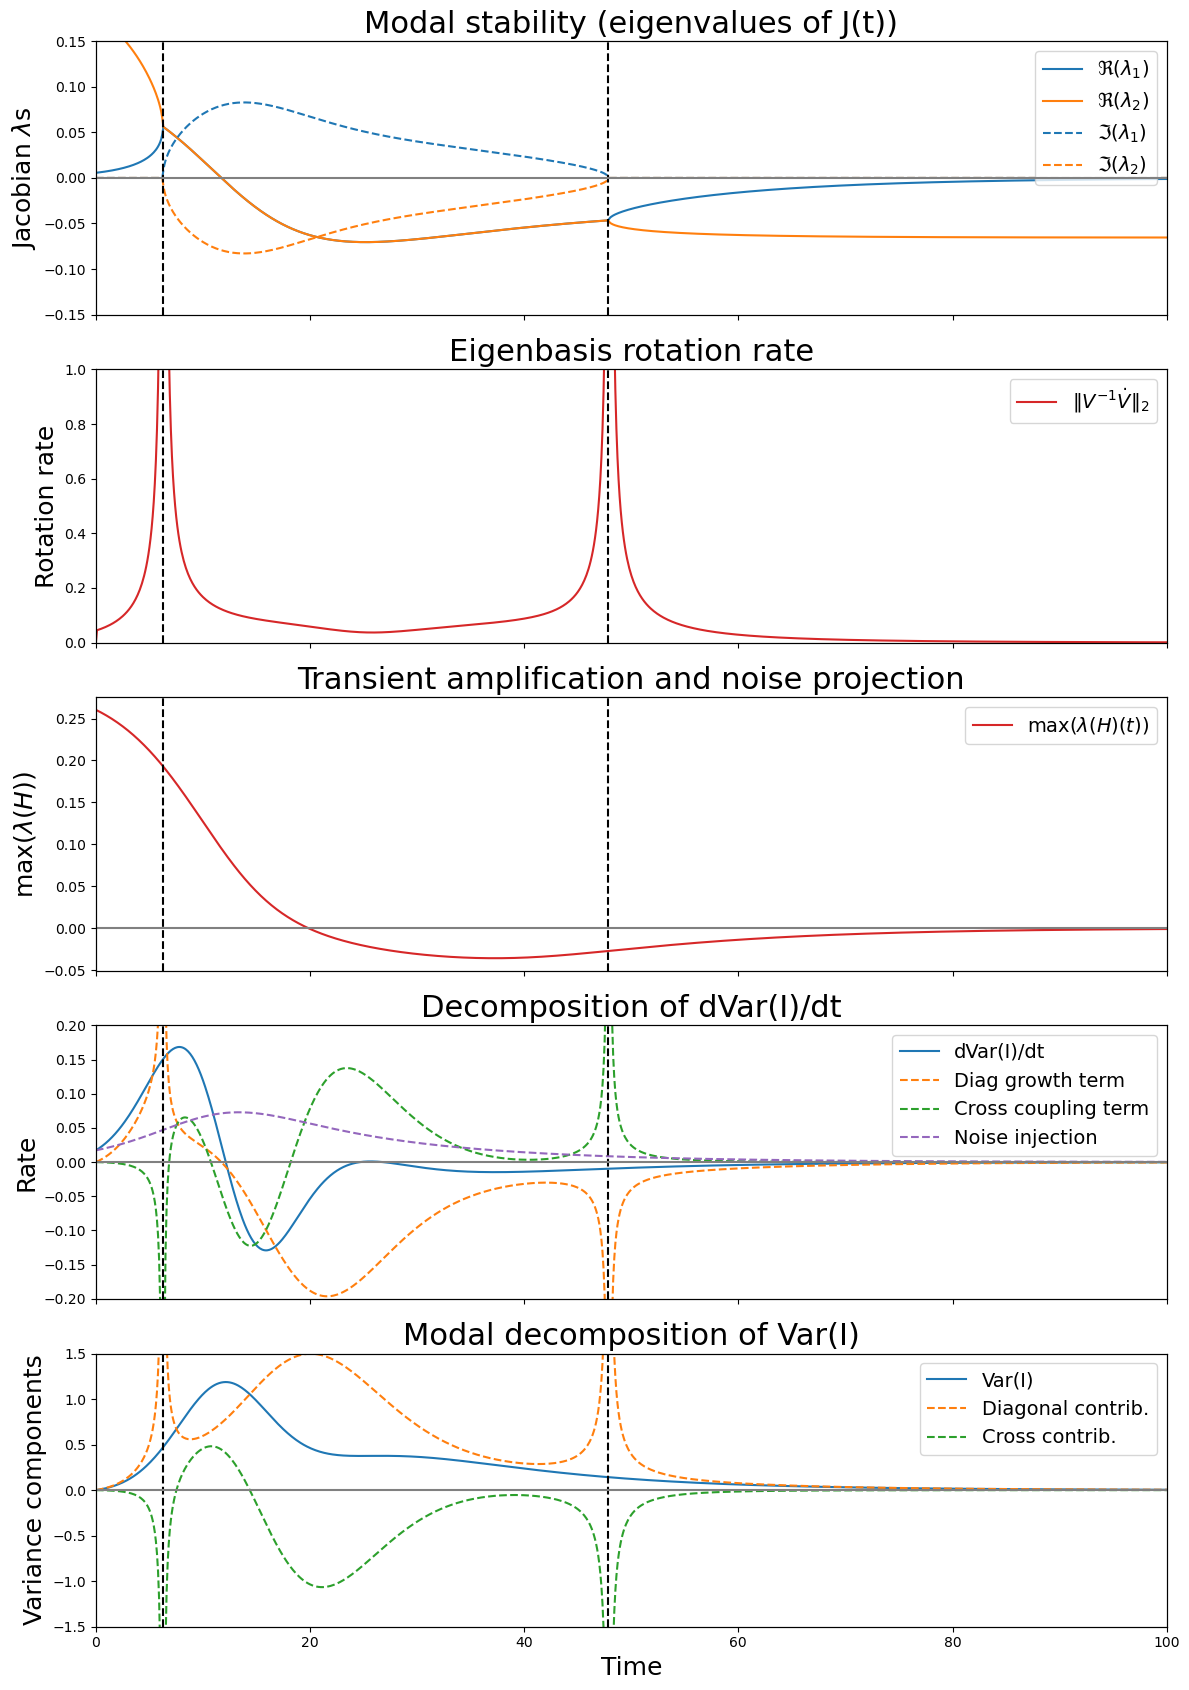

In [110]:
fig, axs = plt.subplots(5, 1, figsize=(12, 17), sharex=True)

# J(t)
axs[0].plot(ts, eig_J_real[:,0], color='tab:blue', label=r'$\Re(\lambda_1)$')
axs[0].plot(ts, eig_J_real[:,1], color='tab:orange', label=r'$\Re(\lambda_2)$')
axs[0].plot(ts, eig_J_imag[:,0], '--', color='tab:blue', label=r'$\Im(\lambda_1)$')
axs[0].plot(ts, eig_J_imag[:,1], '--', color='tab:orange', label=r'$\Im(\lambda_2)$')
axs[0].set_ylabel(r"Jacobian $\lambda$s", fontsize=18)
axs[0].set_title("Modal stability (eigenvalues of J(t))", fontsize=22)
axs[0].legend(loc='upper right', fontsize=14)
axs[0].set_ylim(-0.15,0.15)

# Rotation rate
axs[1].plot(ts, Arot_norm, color='tab:red', label=r"$\|V^{-1}\dot V\|_2$")
axs[1].set_ylabel("Rotation rate", fontsize=18)
axs[1].set_title("Eigenbasis rotation rate", fontsize=22)
axs[1].legend(fontsize=14)
axs[1].set_ylim((0,1))

# H(t)
axs[2].plot(ts, num_abscissa, color='tab:red', label=r'$\max(\lambda(H)(t))$')
axs[2].set_ylabel(r'$\max(\lambda(H))$', fontsize=18)
axs[2].set_title("Transient amplification and noise projection", fontsize=22)
axs[2].legend(loc='upper right', fontsize=14)

# dVar(I)/dt
axs[3].plot(ts, dVarI, label="dVar(I)/dt", color="tab:blue")
axs[3].plot(ts, diag_dot, '--', label="Diag growth term", color="tab:orange")
axs[3].plot(ts, cross_dot, '--', label="Cross coupling term", color="tab:green")
axs[3].plot(ts, noise_dot, '--', label="Noise injection", color="tab:purple")
axs[3].set_title("Decomposition of dVar(I)/dt", fontsize=22)
axs[3].set_ylabel("Rate",fontsize=18)
axs[3].legend(fontsize=14)
axs[3].set_ylim(-0.2,0.2)

# Var(I)
axs[4].plot(ts, VarI_modal, label="Var(I)", color='tab:blue')
axs[4].plot(ts, diag_contrib, '--', label="Diagonal contrib.", color='tab:orange')
axs[4].plot(ts, cross_contrib, '--', label="Cross contrib.", color='tab:green')
axs[4].set_ylabel("Variance components", fontsize=18)
axs[4].set_title("Modal decomposition of Var(I)", fontsize=22)
axs[4].legend(fontsize=14)
axs[4].set_ylim((-1.5,1.5))
axs[4].set_xlabel("Time", fontsize=18)

# Axes limits
for idx in range(5):
    ax = axs[idx].twinx()
    ax.vlines([ts[63],ts[478]],0,1,linestyles='--',color='k')
    ax.set_ylim(0,1)
    ax.set_yticks([])
    if not (idx in [1,2]):
        ax.hlines(0.5,0,100,'grey')
    axs[idx].set_xlim(0,100)
    if idx == 2:
        axs[idx].hlines(0,0,100,'grey')

plt.tight_layout()
plt.show()

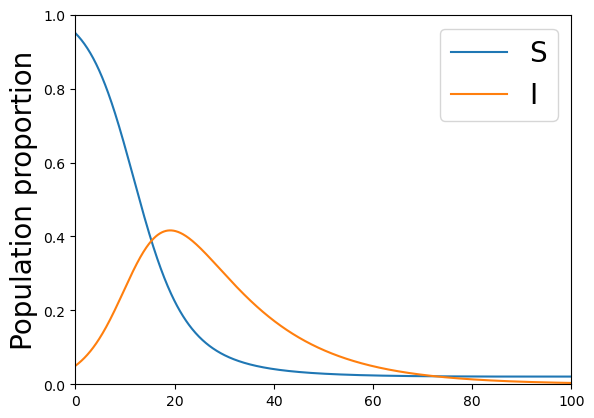

In [111]:
plt.plot(ts, S, label='S', color='tab:blue')
plt.plot(ts, I, label='I', color='tab:orange')
# plt.plot(ts, R, label='R', color='tab:green')
plt.ylabel("Population proportion",fontsize=20)
plt.legend(loc='upper right',fontsize=20)
plt.xlim(0,100)
plt.ylim(0,1)
plt.show()

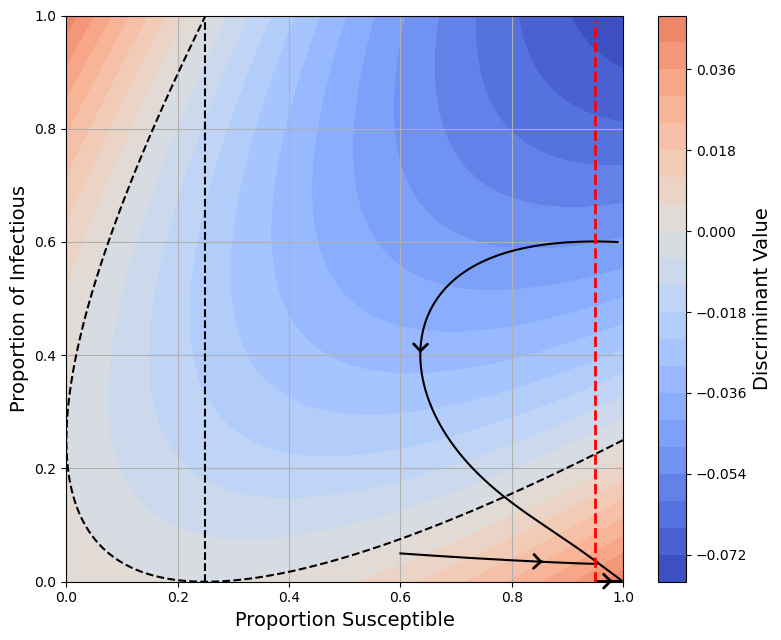

In [112]:
params = {
    'beta': beta0,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': 0.2    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0, 1, 1000)
i_vals = np.linspace(0, 1, 1000)
S, I = np.meshgrid(s_vals, i_vals)

# Lambdify the discriminant
from sympy import lambdify

discriminant_func = lambdify((s, i, beta, g, m), discriminant_simplified, 'numpy')

# Evaluate over the grid
D_vals = discriminant_func(S, I, params['beta'],params['g'], params['mu'])

icS = np.array([0.99, 0.6])
icI = np.array([0.6,0.05])
ts = np.linspace(0,500,5000)
# Plot the discriminant
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(S, I, D_vals, levels=20, vmin=-np.max(np.abs(D_vals)),vmax=np.max(np.abs(D_vals)),cmap='coolwarm')
cbar = plt.colorbar(contour)
# Change tick label size
cbar.set_label('Discriminant Value', fontsize=14)
plt.contour(S, I, D_vals, levels=[0], colors='k', linewidths=1.5, linestyles='--')

for s0, i0 in zip(icS,icI):
    cst_theory = odeint(test_int,[s0,i0,0,0,0,0],ts,args=(betat,1/14,0.2))
    eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts[i],betat,1/14,0.2)) for i in range(len(ts))])
    plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
    mid = len(cst_theory)//80
    plt.annotate('',
                 xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                 xytext=(cst_theory[mid,0], cst_theory[mid,1]),
                arrowprops=dict(
                     arrowstyle='->,head_length=0.5,head_width=0.5',
                     color='black',
                     lw=2))
cst_theory = odeint(test_int,[0.95,0.001,0,0,0,0],ts,args=(betat,1/14,0.2))
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
mid = len(cst_theory)//100
plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))
plt.vlines(x=(gamma+0.2)/beta0, ymin=0, ymax=0.99, color='red', linestyle='--',linewidth=2)
plt.vlines(x=gamma/beta0, ymin=0, ymax=0.99, color='black', linestyle='--')
plt.xlabel('Proportion Susceptible',fontsize = 14)
plt.ylabel('Proportion of Infectious',fontsize = 14)
plt.grid(True)
# plt.xlim(0.248, 1)
# plt.ylim(0, 0.00001)
plt.tight_layout()
plt.show()

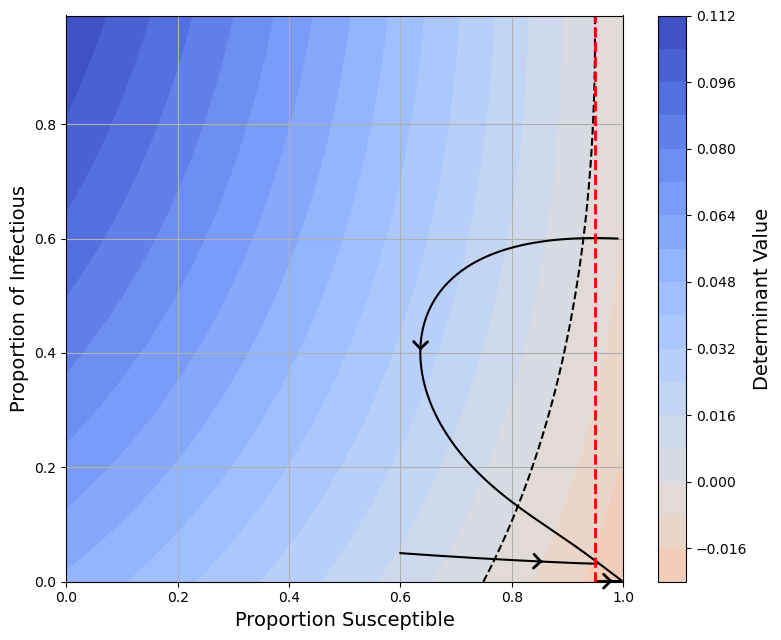

In [113]:
params = {
    'beta': beta0,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': 0.2    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0, 1, 1001)
i_vals = np.linspace(0, 0.99, 1000)
S, I = np.meshgrid(s_vals, i_vals)

# Lambdify the discriminant
from sympy import lambdify

det_func = lambdify((s, i, beta, g, m), det_H, 'numpy')

# Evaluate over the grid
D_vals = det_func(S, I, params['beta'],params['g'], params['mu'])

icS = np.array([0.99, 0.6])
icI = np.array([0.6,0.05])
ts = np.linspace(0,500,5000)
# Plot the det
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(S, I, D_vals, levels=20, vmin=-np.max(np.abs(D_vals)),vmax=np.max(np.abs(D_vals)),cmap='coolwarm_r')
cbar = plt.colorbar(contour)
# Change tick label size
cbar.set_label('Determinant Value', fontsize=14)
plt.contour(S, I, D_vals, levels=[0], colors='k', linewidths=1.5, linestyles='--')
for s0, i0 in zip(icS,icI):
    cst_theory = odeint(test_int,[s0,i0,0,0,0,0],ts,args=(betat,1/14,0.2))
    eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts[i],betat,1/14,0.2)) for i in range(len(ts))])
    plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
    mid = len(cst_theory)//80
    plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))
cst_theory = odeint(test_int,[0.95,0.001,0,0,0,0],ts,args=(betat,1/14,0.2))
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
plt.vlines(x=(gamma+0.2)/beta0, ymin=0, ymax=0.99, color='red', linestyle='--',linewidth=2)
plt.xlabel('Proportion Susceptible',fontsize = 14)
plt.ylabel('Proportion of Infectious',fontsize = 14)
mid = len(cst_theory)//100
plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))
plt.grid(True)
plt.tight_layout()
plt.show()

In [114]:
b1 = 0.06
betat = lambda x: b1
b1/(gamma+0.00003424657)

0.8395974533385939

In [115]:
# ICs and Theoretical solution
X0 = [0.9, 0.1, 0, 0, 0, 0]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]

# ICs and outputs
eig_J_real, eig_J_imag = [], []
eig_sym, num_abscissa, proj_amp, dVarI = [], [], [], []
det_sym = []
VarI_modal, g_store, diag_contrib, cross_contrib = [], [], [], []
VarI_H, g_H_store, diag_contrib_H, cross_contrib_H = [], [], [], []
V_store, Vinv_store = [], []
diag_dot, cross_dot, noise_dot = [], [], []
e_I = np.array([0,1])
Arot_norm = [0]

for idx, X in enumerate(sol):
    A = jac(X, ts[idx], betat, gamma, mu)
    Q = Q_calc(X, ts[idx], betat, gamma, mu)
    Sigma = np.array([[X[3], X[4]], [X[4], X[5]]])
    
    # J(t) values
    w, V = np.linalg.eig(A)
    V_inv = np.linalg.inv(V)
    eig_J_real.append(np.real(w))
    eig_J_imag.append(np.imag(w))
    Vinv_store.append(V_inv.copy())
    Lambda = np.diag(w)

    # Var(I) decomp
    S_modal = V_inv @ Sigma @ V_inv.conj().T
    Q_modal = np.array(V_inv @ Q @ V_inv.conj().T)

    # dVar(I)/dt
    K = A @ Sigma + Sigma @ A.T + Q
    dVarI.append(K[1,1])
    
    # H(t) def
    sym = (A + A.T)/2
    ws, vs = np.linalg.eig(sym)
    eig_sym.append(ws)
    num_abscissa.append(np.max(ws))
    det_sym.append(np.linalg.det(sym))
    
    # H(t)
    vmax = vs[:, np.argmax(ws)]
    G = vmax.T @ Q @ vmax
    proj_amp.append(np.real(G))
    
    
    # Var(I) decomp
    varI_m, g_J, dpart, cpart = varI_from_modal(np.array(V), Sigma, e_I)
    VarI_modal.append(varI_m)
    g_store.append(g_J)
    diag_contrib.append(dpart)
    cross_contrib.append(cpart)

    # dVar(I) decomp
    diag_d = np.sum(2*np.real(np.diag(Lambda)) * (np.abs(g_J)**2) * np.real(np.diag(S_modal)))
    cross_d = np.real(K[1,1] - diag_d - np.real(np.vdot(g_J, Q_modal @ g_J)))
    noise_d = np.real(np.vdot(g_J, Q_modal @ g_J))
    diag_dot.append(diag_d)
    cross_dot.append(cross_d)
    noise_dot.append(noise_d)

    # H(t) var
    varI_h, g_h, dpart_h, cpart_h = varI_from_H(sym, Sigma, e_I)
    VarI_H.append(varI_h)
    g_H_store.append(g_h)
    diag_contrib_H.append(dpart_h)
    cross_contrib_H.append(cpart_h)

    # Fix rotation rate
    if idx == 0:
        V_prev = V.copy()
        V_store = [V.copy()]
        perm_store = [np.arange(V.shape[1])]
    else:
        V_aligned, perm = match_and_phase_align(V_prev, V)
        # optional: detect 2x2 blocks where eigenvalues are close and align subspace instead
        V_store.append(V_aligned.copy())
        perm_store.append(perm)
        # estimate derivative:
        dt = ts[idx] - ts[idx-1]
        dV = (V_aligned - V_prev) / dt
        A_est = np.linalg.inv(V_prev) @ dV
        Arot_norm.append(np.linalg.norm(A_est, ord='fro'))
        V_prev = V_aligned.copy()

# Arrays for plotting
eig_J_real = np.array(eig_J_real)
eig_J_imag = np.array(eig_J_imag)
eig_sym = np.array(eig_sym)
num_abscissa = np.array(num_abscissa)
proj_amp = np.array(proj_amp).flatten()
dVarI = np.array(dVarI)
VarI_modal = np.array(VarI_modal)
diag_contrib = np.array(diag_contrib)
cross_contrib = np.array(cross_contrib)
g_store = np.array(g_store)
VarI_H = np.array(VarI_H)
diag_contrib_H = np.array(diag_contrib_H)
cross_contrib_H = np.array(cross_contrib_H)
g_H_store = np.array(g_H_store)
diag_dot = np.array(diag_dot)
cross_dot = np.array(cross_dot)
noise_dot = np.array(noise_dot)

/tmp/ipykernel_333600/1002991493.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  Vc[:, i] = Vc[:, i] * np.conj(phase)


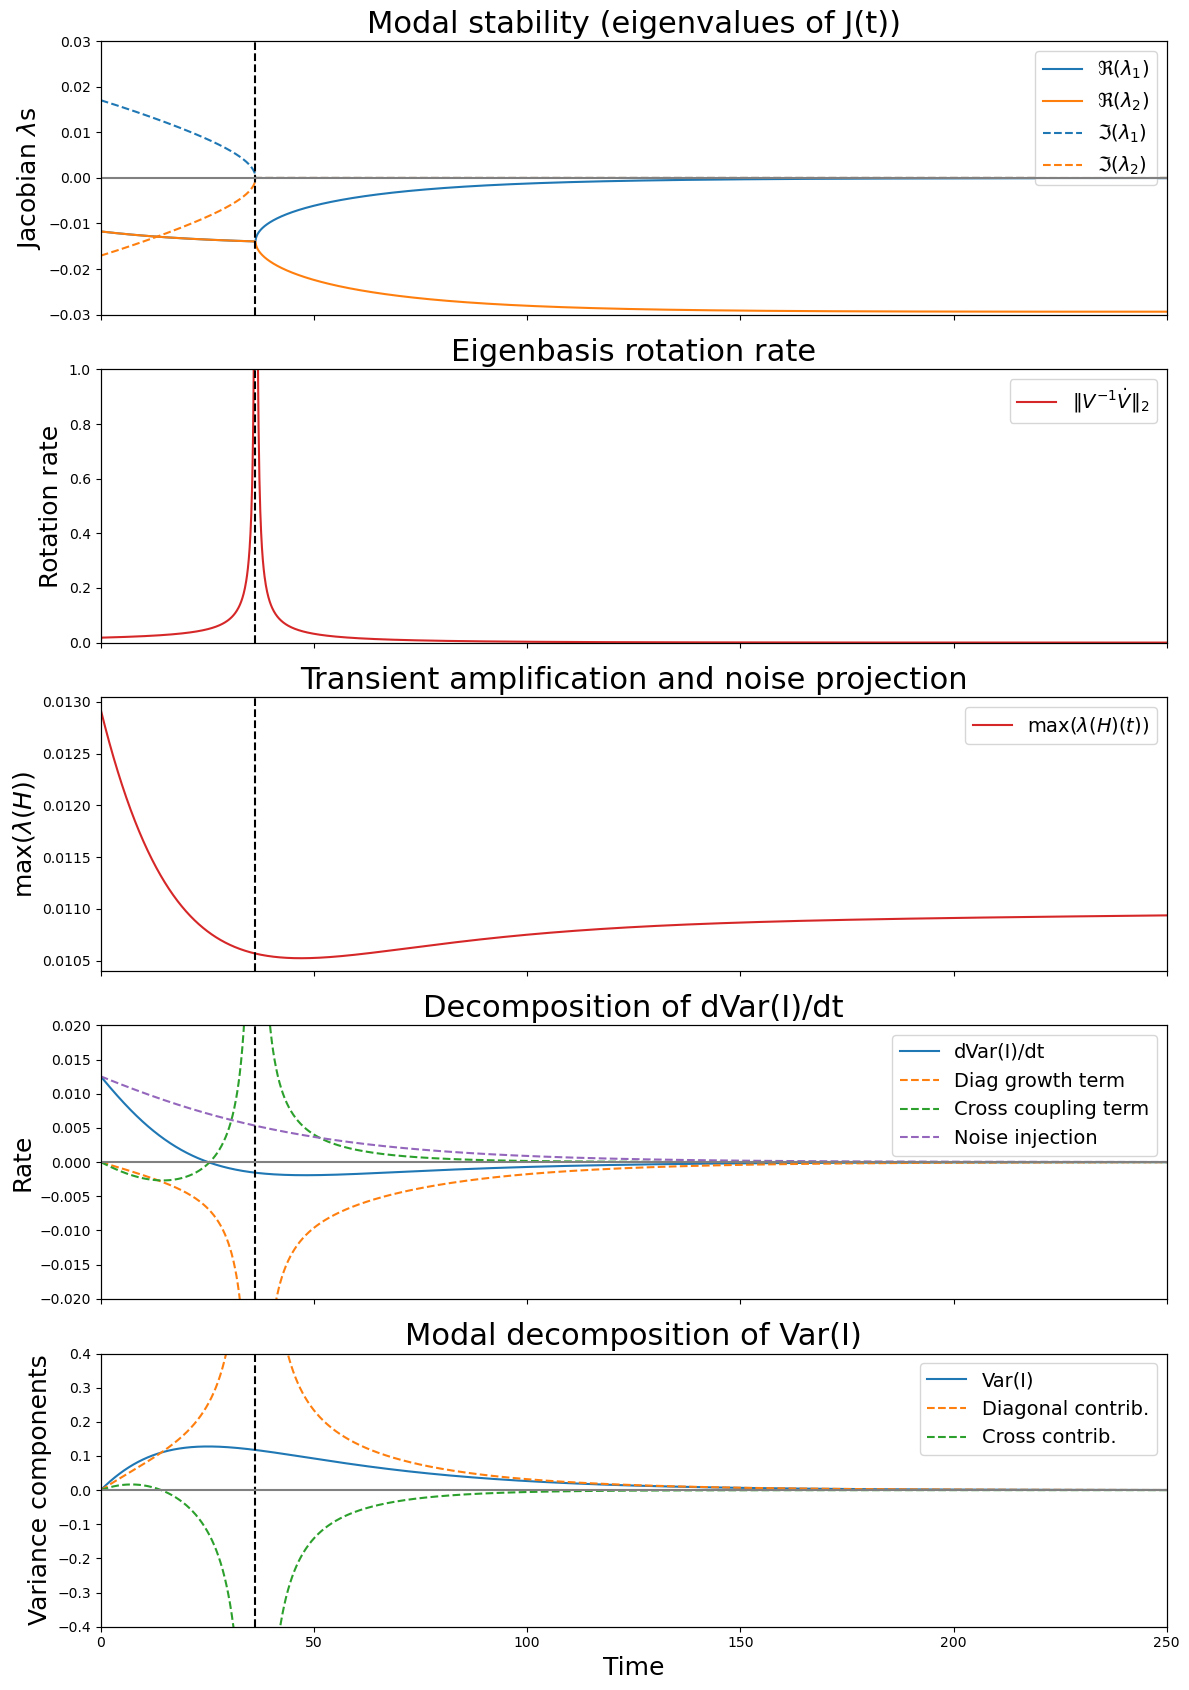

In [117]:
fig, axs = plt.subplots(5, 1, figsize=(12, 17), sharex=True)

# J(t)
axs[0].plot(ts, eig_J_real[:,0], color='tab:blue', label=r'$\Re(\lambda_1)$')
axs[0].plot(ts, eig_J_real[:,1], color='tab:orange', label=r'$\Re(\lambda_2)$')
axs[0].plot(ts, eig_J_imag[:,0], '--', color='tab:blue', label=r'$\Im(\lambda_1)$')
axs[0].plot(ts, eig_J_imag[:,1], '--', color='tab:orange', label=r'$\Im(\lambda_2)$')
axs[0].set_ylabel(r"Jacobian $\lambda$s", fontsize=18)
axs[0].set_title("Modal stability (eigenvalues of J(t))", fontsize=22)
axs[0].legend(loc='upper right', fontsize=14)
axs[0].set_ylim(-0.03,0.03)

# Rotation rate
axs[1].plot(ts, Arot_norm, color='tab:red', label=r"$\|V^{-1}\dot V\|_2$")
axs[1].set_ylabel("Rotation rate", fontsize=18)
axs[1].set_title("Eigenbasis rotation rate", fontsize=22)
axs[1].legend(fontsize=14)
axs[1].set_ylim((0,1))

# H(t)
axs[2].plot(ts, num_abscissa, color='tab:red', label=r'$\max(\lambda(H)(t))$')
axs[2].set_ylabel(r'$\max(\lambda(H))$', fontsize=18)
axs[2].set_title("Transient amplification and noise projection", fontsize=22)
axs[2].legend(loc='upper right', fontsize=14)

# dVar/dt
axs[3].plot(ts, dVarI, label="dVar(I)/dt", color="tab:blue")
axs[3].plot(ts, diag_dot, '--', label="Diag growth term", color="tab:orange")
axs[3].plot(ts, cross_dot, '--', label="Cross coupling term", color="tab:green")
axs[3].plot(ts, noise_dot, '--', label="Noise injection", color="tab:purple")
axs[3].set_title("Decomposition of dVar(I)/dt", fontsize=22)
axs[3].set_ylabel("Rate",fontsize=18)
axs[3].legend(fontsize=14)
axs[3].set_ylim(-0.02,0.02)

# Var(I)
axs[4].plot(ts, VarI_modal, label="Var(I)", color='tab:blue')
axs[4].plot(ts, diag_contrib, '--', label="Diagonal contrib.", color='tab:orange')
axs[4].plot(ts, cross_contrib, '--', label="Cross contrib.", color='tab:green')
axs[4].set_ylabel("Variance components", fontsize=18)
axs[4].set_title("Modal decomposition of Var(I)", fontsize=22)
axs[4].legend(fontsize=14)
axs[4].set_ylim((-0.4,0.4))
axs[4].set_xlabel("Time", fontsize=18)

# Axes limits
for idx in range(5):
    ax = axs[idx].twinx()
    ax.vlines(ts[362],0,1,linestyles='--',color='k')
    ax.set_ylim(0,1)
    ax.set_yticks([])
    if not (idx in [1,2]):
        ax.hlines(0.5,0,250,'grey')
    axs[idx].set_xlim(0,250)

plt.tight_layout()
plt.show()

(0.0, 1.0)

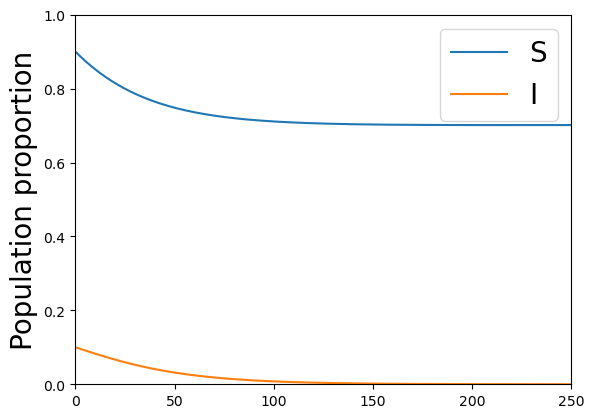

In [92]:
plt.plot(ts, S, label='S', color='tab:blue')
plt.plot(ts, I, label='I', color='tab:orange')
# plt.plot(ts, R, label='R', color='tab:green')
plt.ylabel("Population proportion",fontsize=20)
plt.legend(loc='upper right',fontsize=20)
plt.xlim(0,250)
plt.ylim(0,1)

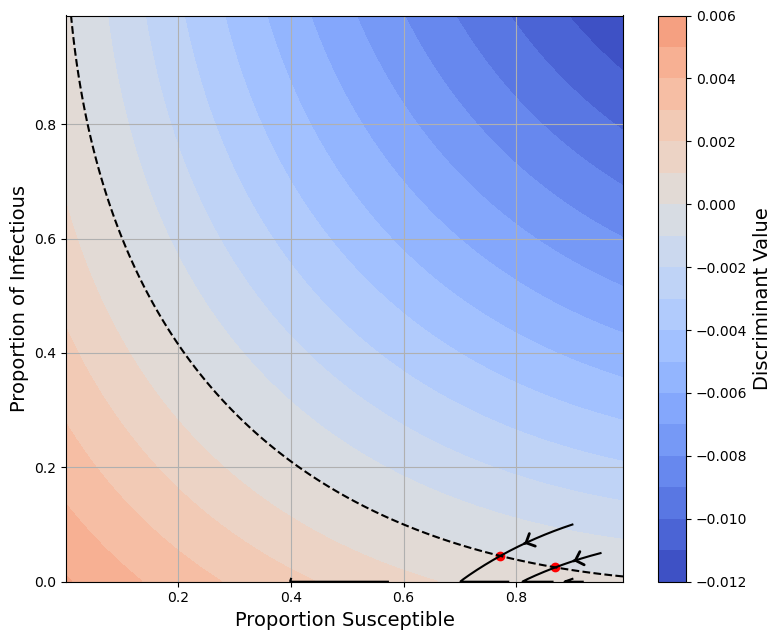

In [138]:
params = {
    'beta': b1,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': mu    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0.001, 0.99, 400)
i_vals = np.linspace(0.001, 0.99, 400)
S, I = np.meshgrid(s_vals, i_vals)

# Evaluate over the grid
D_vals = discriminant_func(S, I, params['beta'],params['g'], params['mu'])

icS = np.array([0.9, 0.95])
icI = 1 - icS
# Plot the discriminant
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(S, I, D_vals, levels=20, vmin=-np.max(np.abs(D_vals)),vmax=np.max(np.abs(D_vals)),cmap='coolwarm')
cbar = plt.colorbar(contour)
# Change tick label size
cbar.set_label('Discriminant Value', fontsize=14)
plt.contour(S, I, D_vals, levels=[0], colors='k', linewidths=1.5, linestyles='--')
for s0, i0 in zip(icS,icI):
    cst_theory = odeint(test_int,[s0,i0,0,0,0,0],ts2,args=(betat,1/14,0.00003424657))
    eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts2[i],betat,1/14,0.00003424657)) for i in range(len(ts2))])
    if len(np.where(np.iscomplex(eigvals_theory[:,0]))[0]) > 0:
        id2 = np.where(np.iscomplex(eigvals_theory[:,0]))[0][-1]
        plt.scatter(cst_theory[id2,0], cst_theory[id2,1], color='red')
    plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
    mid = len(cst_theory)//500
    plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))
cst_theory = odeint(test_int,[0.4,0.005,1-0.4-0.005,0,0,0],ts2,args=(betat,1/14,0.00003424657))
eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts2[i],betat,1/14,0.00003424657)) for i in range(len(ts2))])
if len(np.where(np.iscomplex(eigvals_theory[:,0]))[0]) > 0:
    id2 = np.where(np.iscomplex(eigvals_theory[:,0]))[0][-1]
    plt.scatter(cst_theory[id2,0], cst_theory[id2,1], color='red')
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
cst_theory = odeint(test_int,[0.9,0.005,1-0.4-0.005,0,0,0],ts2,args=(betat,1/14,0.00003424657))
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
plt.xlabel('Proportion Susceptible',fontsize = 14)
plt.ylabel('Proportion of Infectious',fontsize = 14)
plt.grid(True)
plt.ylim(0,None)
plt.tight_layout()
plt.show()

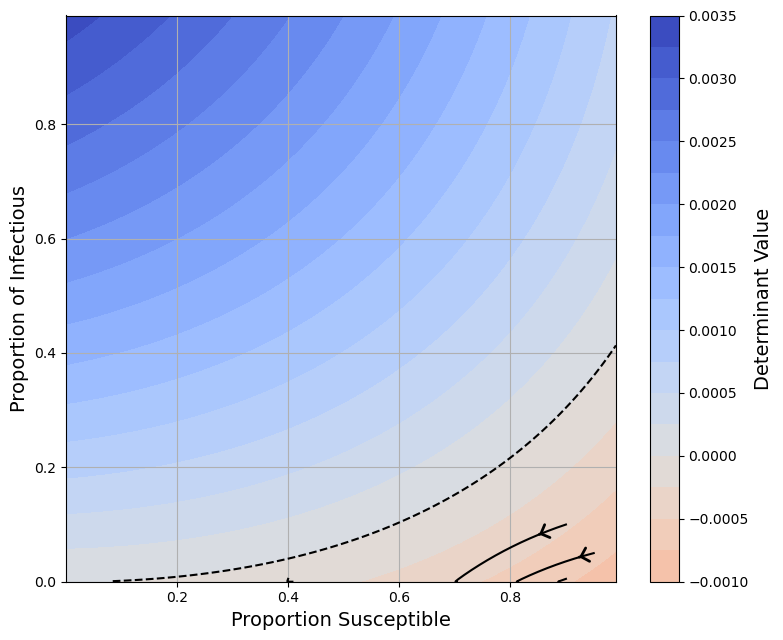

In [139]:
params = {
    'beta': b1,  # transmission rate
    'g': gamma,     # recovery rate
    'mu': mu    # mortality rate
}

# Generate a range of s and i values over a plausible domain
s_vals = np.linspace(0.001, 0.99, 400)
i_vals = np.linspace(0.001, 0.99, 400)
S, I = np.meshgrid(s_vals, i_vals)

# Evaluate over the grid
D_vals = det_func(S, I, params['beta'],params['g'], params['mu'])

icS = np.array([0.9, 0.95])
icI = 1 - icS
ts = np.linspace(0,500,5000)
# Plot the det
plt.figure(figsize=(8, 6.5))
contour = plt.contourf(S, I, D_vals, levels=20, vmin=-np.max(np.abs(D_vals)),vmax=np.max(np.abs(D_vals)),cmap='coolwarm_r')
cbar = plt.colorbar(contour)
# Change tick label size
cbar.set_label('Determinant Value', fontsize=14)
plt.contour(S, I, D_vals, levels=[0], colors='k', linewidths=1.5, linestyles='--')
for s0, i0 in zip(icS,icI):
    cst_theory = odeint(test_int,[s0,i0,0,0,0,0],ts,args=(betat,1/14,0.00003424657))
    eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts[i],betat,1/14,0.00003424657)) for i in range(len(ts))])
    plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
    mid = len(cst_theory)//50
    plt.annotate('',
                xy=(cst_theory[mid+1,0], cst_theory[mid+1,1]),
                xytext=(cst_theory[mid,0], cst_theory[mid,1]),
            arrowprops=dict(
                    arrowstyle='->,head_length=0.5,head_width=0.5',
                    color='black',
                    lw=2))
cst_theory = odeint(test_int,[0.4,0.005,1-0.4-0.005,0,0,0],ts,args=(betat,1/14,0.00003424657))
eigvals_theory = np.array([np.linalg.eigvals(jac(cst_theory[i,:],ts[i],betat,1/14,0.00003424657)) for i in range(len(ts))])
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
cst_theory = odeint(test_int,[0.9,0.005,1-0.4-0.005,0,0,0],ts,args=(betat,1/14,0.00003424657))
plt.plot(cst_theory[:,0], cst_theory[:,1], color='black', linestyle='-')
plt.xlabel('Proportion Susceptible',fontsize = 14)
plt.ylabel('Proportion of Infectious',fontsize = 14)
# plt.title('det of Characteristic Polynomial',fontsize = 18)
plt.grid(True)
plt.ylim(0,None)
plt.tight_layout()
plt.show()